In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4179s 25us/step
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

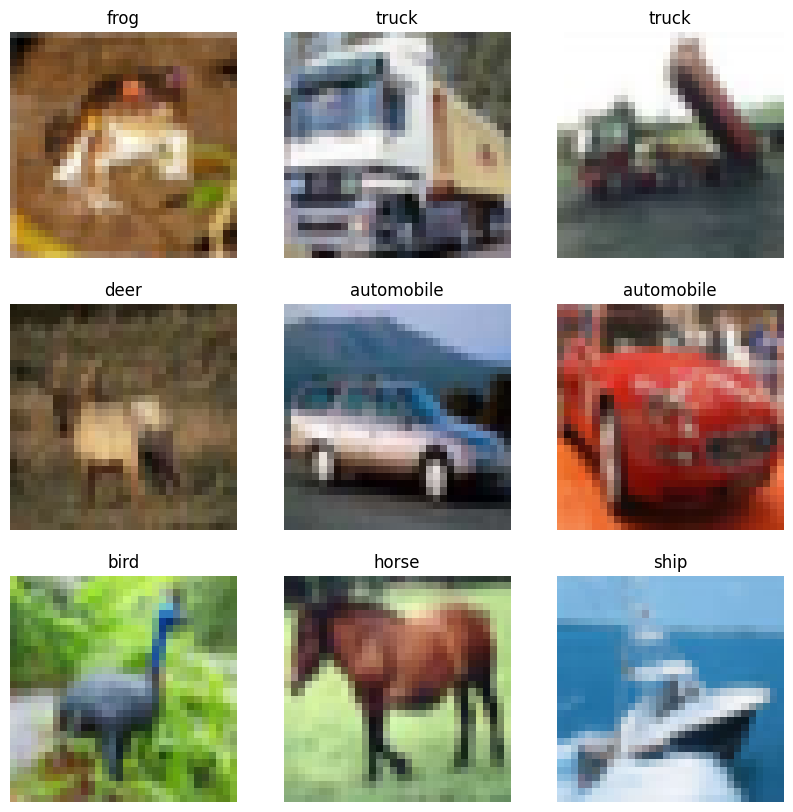

In [4]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [5]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
ann_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
ann_history = ann_model.fit(x_train, y_train,
                             validation_data=(x_test, y_test),
                             epochs=10,
                             batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.2422 - loss: 2.0415 - val_accuracy: 0.3236 - val_loss: 1.8553
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.2920 - loss: 1.9061 - val_accuracy: 0.3466 - val_loss: 1.8214
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3102 - loss: 1.8704 - val_accuracy: 0.3552 - val_loss: 1.8162
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3220 - loss: 1.8442 - val_accuracy: 0.3690 - val_loss: 1.7560
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3311 - loss: 1.8186 - val_accuracy: 0.4013 - val_loss: 1.7205
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3390 - loss: 1.8036 - val_accuracy: 0.3857 - val_loss: 1.7277
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3450 - loss: 1.7862 - val_accuracy: 0.3909 - val_loss: 1.7281
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3491 - loss: 1.7792 - 

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

In [10]:
cnn_history = cnn_model.fit(x_train, y_train,
                             validation_data=(x_test, y_test),
                             epochs=10,
                             batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 81ms/step - accuracy: 0.4650 - loss: 1.4979 - val_accuracy: 0.5697 - val_loss: 1.2653
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.5982 - loss: 1.1330 - val_accuracy: 0.5925 - val_loss: 1.2011
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 83ms/step - accuracy: 0.6560 - loss: 0.9780 - val_accuracy: 0.6743 - val_loss: 0.9297
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.6928 - loss: 0.8722 - val_accuracy: 0.7006 - val_loss: 0.8813
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.7235 - loss: 0.7872 - val_accuracy: 0.6905 - val_loss: 0.8939
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.7443 - loss: 0.7193 - val_accuracy: 0.7213 - val_loss: 0.8343
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.7695 - loss: 0.6491 - val_accuracy: 0.7130 - val_loss: 0.8530
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.7947 - loss: 0.5818 - 

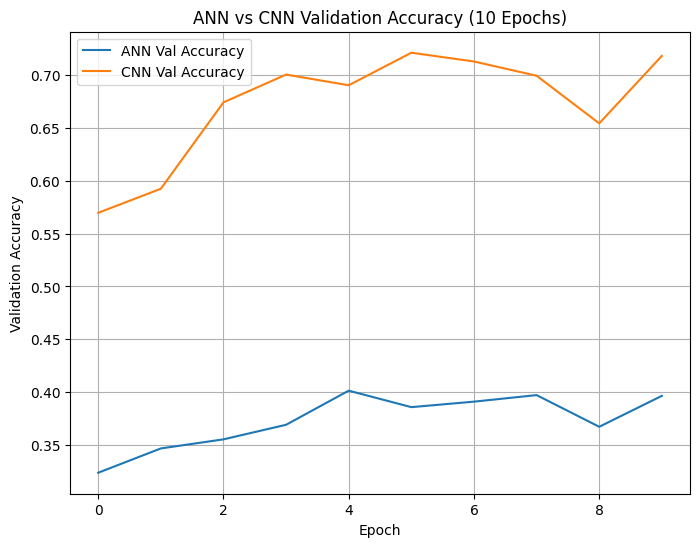

In [11]:
plt.figure(figsize=(8,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('ANN vs CNN Validation Accuracy (10 Epochs)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
ann_model_v2 = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

ann_model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
ann_v2_history = ann_model_v2.fit(x_train, y_train,
                                   validation_data=(x_test, y_test),
                                   epochs=10,
                                   batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.2103 - loss: 2.1023 - val_accuracy: 0.2842 - val_loss: 1.9775
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.2518 - loss: 1.9872 - val_accuracy: 0.2912 - val_loss: 1.9181
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.2643 - loss: 1.9573 - val_accuracy: 0.3210 - val_loss: 1.8996
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.2783 - loss: 1.9312 - val_accuracy: 0.3297 - val_loss: 1.8698
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.2849 - loss: 1.9172 - val_accuracy: 0.3448 - val_loss: 1.8507
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.2923 - loss: 1.9057 - val_accuracy: 0.3282 - val_loss: 1.8430
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.2975 - loss: 1.8937 - val_accuracy: 0.3594 - val_loss: 1.8366
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.3002 - loss: 1.8866 - 

In [14]:
cnn_model_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

cnn_model_v2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_v2_history = cnn_model_v2.fit(x_train, y_train,
                                   validation_data=(x_test, y_test),
                                   epochs=20,
                                   batch_size=64,
                                   callbacks=[early_stop])

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 114ms/step - accuracy: 0.4921 - loss: 1.4498 - val_accuracy: 0.5696 - val_loss: 1.2400
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 114ms/step - accuracy: 0.6363 - loss: 1.0333 - val_accuracy: 0.6731 - val_loss: 0.9335
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.6975 - loss: 0.8650 - val_accuracy: 0.6678 - val_loss: 0.9344
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.7391 - loss: 0.7484 - val_accuracy: 0.7349 - val_loss: 0.7745
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.7693 - loss: 0.6599 - val_accuracy: 0.7090 - val_loss: 0.8780
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 111ms/step - accuracy: 0.7933 - loss: 0.5868 - val_accuracy: 0.6969 - val_loss: 0.9209
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 112ms/step - accuracy: 0.8174 - loss: 0.5181 - val_accuracy: 0.7508 - val_loss: 0.7629
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 111ms/step - accuracy: 0.8377 - loss:

In [16]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

aug_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

aug_history = aug_model.fit(x_train, y_train,
                             validation_data=(x_test, y_test),
                             epochs=20,
                             batch_size=64,
                             callbacks=[early_stop])

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 121ms/step - accuracy: 0.4154 - loss: 1.6388 - val_accuracy: 0.5379 - val_loss: 1.2837
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.5194 - loss: 1.3484 - val_accuracy: 0.6081 - val_loss: 1.1001
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 118ms/step - accuracy: 0.5707 - loss: 1.2123 - val_accuracy: 0.6041 - val_loss: 1.1025


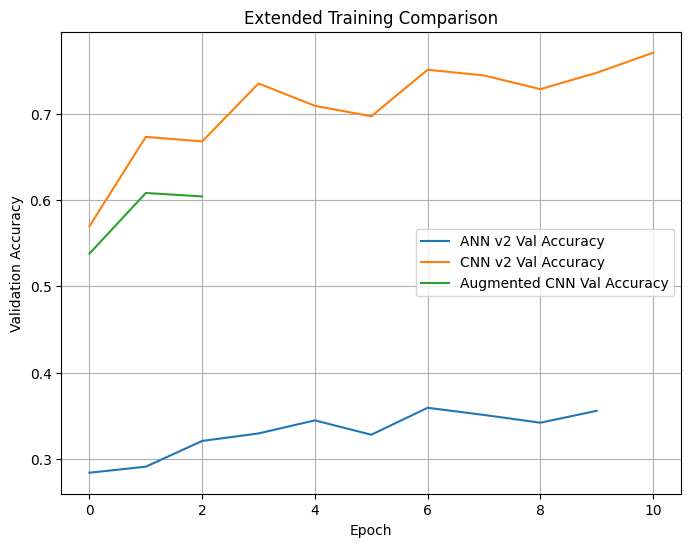

In [17]:
plt.figure(figsize=(8,6))
plt.plot(ann_v2_history.history['val_accuracy'], label='ANN v2 Val Accuracy')
plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN v2 Val Accuracy')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Extended Training Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)

ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test, y_test, verbose=0)
cnn_v2_test_loss, cnn_v2_test_acc = cnn_model_v2.evaluate(x_test, y_test, verbose=0)

aug_test_loss, aug_test_acc = aug_model.evaluate(x_test, y_test, verbose=0)

results_df = pd.DataFrame({
    "Model": ["ANN Baseline", "CNN Baseline", "ANN Deeper", "CNN Scaled Filters", "CNN Augmented"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_v2_test_acc, cnn_v2_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, ann_v2_test_loss, cnn_v2_test_loss, aug_test_loss]
})

results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Test Accuracy,Test Loss
0,CNN Scaled Filters,0.7442,0.757423
1,CNN Baseline,0.7183,0.891753
2,CNN Augmented,0.5379,1.283692
3,ANN Baseline,0.3964,1.714877
4,ANN Deeper,0.3559,1.814215
